In [72]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch import nn
import torch
import torchvision
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import shap
import numpy as np

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [15]:
device

'cuda'

In [16]:
df = pd.read_csv(r'C:\Users\iqvbr\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2\HAM10000_metadata.csv')

In [17]:
df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

In [18]:
df['image_id'][0]

'ISIC_0027419'

In [19]:
placeholder = dict(df['dx'].value_counts())

<BarContainer object of 7 artists>

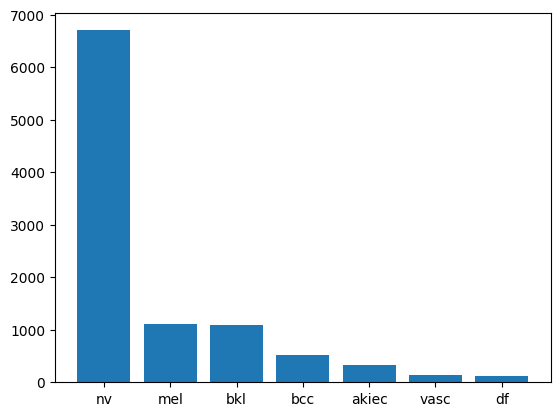

In [20]:
plt.bar(list(placeholder.keys()),list(placeholder.values()))

In [21]:
path = Path(r'C:\Users\iqvbr\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2\all_images')

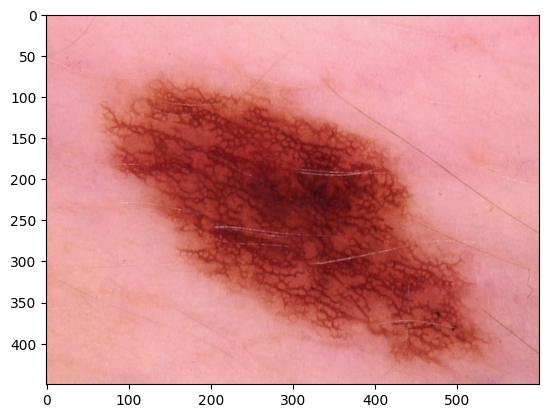

In [22]:
i=0
for img in path.iterdir():
    i+=1
    if i<=3:
        plt.imshow(Image.open(img))
    else:
        break

In [23]:
counter = {}
for img in path.iterdir():
    image = Image.open(img)
    size = image.size
    if size in counter:
        counter[size]+=1
    else:
        counter[size]=1

In [24]:
print(counter)
#all images have size (600,450)

{(600, 450): 10015}


In [25]:
df.head(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [26]:
df['dx'].unique()

array(['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec'], dtype=object)

In [27]:
dx_to_int = {'bkl':0, 'nv':1, 'df':2, 'mel':3, 'vasc':4, 'bcc':5, 'akiec':6}

In [28]:
df['dx'] = df['dx'].map(dx_to_int)

In [29]:
train_transform = transforms.Compose([transforms.Resize((256)), transforms.RandomCrop(224),transforms.RandomHorizontalFlip(),
                                transforms.RandomRotation(30), transforms.RandomVerticalFlip(),transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                     std=[0.229, 0.224, 0.225])])
test_transform = transforms.Compose([transforms.Resize((256)), transforms.CenterCrop(224),transforms.ToTensor(),
                                     transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                     std=[0.229, 0.224, 0.225])])

In [30]:
train_df,test_df = train_test_split(df,random_state=1,shuffle=True,stratify=df['dx'])

In [31]:
train_df['dx'].value_counts().sort_index()

dx
0     824
1    5029
2      86
3     835
4     107
5     385
6     245
Name: count, dtype: int64

In [32]:
class HAMFolder(Dataset):
    def __init__(self, df, dir, transform):
        self.df = df
        self.dir = dir
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self,idx):
        img_path = Path(self.dir, self.df.iloc[idx,1]+'.jpg') 
        img = Image.open(img_path)
        label=torch.tensor(self.df.iloc[idx,2],dtype=torch.long)
        img = self.transform(img)
        return img,label
train_folder = HAMFolder(df=train_df,dir=path,transform=train_transform)
test_folder = HAMFolder(df=test_df,dir=path,transform=test_transform)

In [33]:
train_dataloader = DataLoader(train_folder,32,True)
test_dataloader = DataLoader(test_folder,32,False)

In [34]:
len(train_folder)

7511

In [35]:
test_df['dx'].value_counts()

dx
1    1676
3     278
0     275
5     129
6      82
4      35
2      29
Name: count, dtype: int64

In [36]:
train_counts = train_df['dx'].value_counts().sort_index()
class_weights = 1.0 / torch.tensor(train_counts.values, dtype=torch.float)
loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))

In [37]:
weights = torchvision.models.MobileNet_V2_Weights.DEFAULT
model = torchvision.models.mobilenet_v2(weights=weights)

In [38]:
for param in model.parameters():
    param.requires_grad = False

In [39]:
for param in model.features[15:].parameters():
    param.requires_grad = True

In [40]:
model.classifier = nn.Sequential(nn.Dropout(p=0.2), nn.Linear(1280,7))

In [41]:
model = model.to(device)

In [42]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [43]:
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,20,0.6)

In [44]:
def get_acc(pred,y):
    pred=torch.argmax(pred,dim=1)
    return torch.eq(pred,y).sum().item()

In [45]:
def train_step(model,data,loss_function,optim,device):
    total_acc=0
    model.train()
    for X,y in data:
        X,y=X.to(device),y.to(device)
        optim.zero_grad()
        logits = model(X)
        total_acc+=get_acc(logits,y)
        loss = loss_function(logits,y)
        loss.backward()
        optim.step()
    return total_acc/len(data.dataset)

def test_step(model,data,device):
    total_acc=0
    model.eval()
    with torch.inference_mode():
        for X,y in data:
            X,y=X.to(device),y.to(device)
            logits = model(X)
            total_acc+=get_acc(logits,y)
    return total_acc/len(data.dataset)

In [ ]:
best_acc = 0
for epoch in range(1,51):
    train_acc = train_step(model,train_dataloader,loss_fn,optimizer,device)
    test_acc = test_step(model,test_dataloader,device)
    print(f'Epoch {epoch}\nTrain_acc: {train_acc} Test_acc: {test_acc}')
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')
    scheduler.step()

Epoch 1
Train_acc: 0.5991212887764612 Test_acc: 0.6861022364217252
early stopping
Epoch 2
Train_acc: 0.6581014512048995 Test_acc: 0.694888178913738
early stopping
Epoch 3
Train_acc: 0.6929836240181068 Test_acc: 0.6601437699680511
Epoch 4
Train_acc: 0.7044334975369458 Test_acc: 0.6805111821086262
Epoch 5
Train_acc: 0.7228065503927573 Test_acc: 0.7136581469648562
early stopping
Epoch 6
Train_acc: 0.7109572626814006 Test_acc: 0.7440095846645367
early stopping
Epoch 7
Train_acc: 0.7379842897084277 Test_acc: 0.7048722044728435
Epoch 8
Train_acc: 0.729064039408867 Test_acc: 0.7340255591054313
Epoch 9
Train_acc: 0.7406470509918786 Test_acc: 0.7144568690095847
Epoch 10
Train_acc: 0.7358540806816669 Test_acc: 0.7116613418530351
Epoch 11
Train_acc: 0.7582212754626547 Test_acc: 0.7452076677316294
early stopping
Epoch 12
Train_acc: 0.7638130741579018 Test_acc: 0.7012779552715654
Epoch 13
Train_acc: 0.7737984289708427 Test_acc: 0.7751597444089456
early stopping
Epoch 14
Train_acc: 0.777126880575156

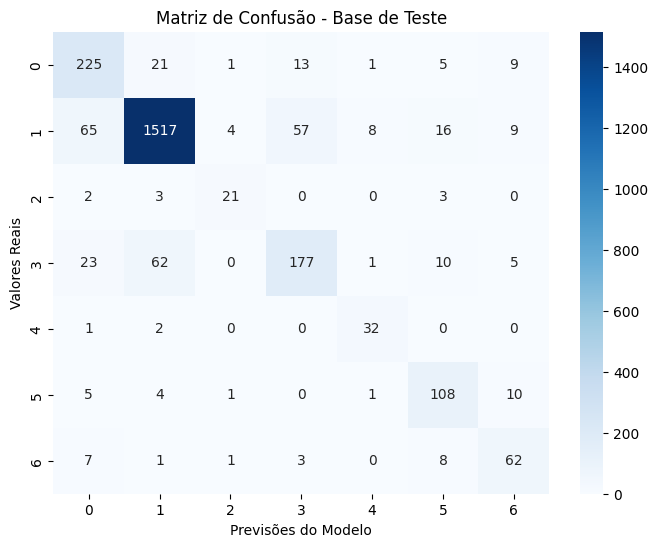

In [47]:
# 1. Listas vazias para acumular os resultados de todos os lotes (batches)
all_preds = []
all_targets = []

# 2. Colocar o modelo em modo de avaliação (desativa Dropout, ajusta BatchNorm, etc.)
model.eval()

# 3. Desligar o cálculo de gradientes (economiza memória e deixa muito mais rápido)
with torch.inference_mode(): # Use torch.no_grad() se o seu PyTorch for mais antigo
    # Passar por todos os dados de teste
    for X, y in test_dataloader:
        # Mover os dados para o mesmo device do modelo (GPU/CPU)
        X, y = X.to(device), y.to(device)
        
        # Fazer a previsão (forward pass)
        logits = model(X)
        
        # Obter a classe prevista
        preds = torch.argmax(logits, dim=1)
        
        # Guardar nas listas (trazendo para a CPU para não lotar a memória da placa de vídeo)
        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

# 4. Juntar as listas de tensores em um tensor único e converter para NumPy
all_preds_np = torch.cat(all_preds).numpy()
all_targets_np = torch.cat(all_targets).numpy()

# 5. Calcular e desenhar a matriz
cm = confusion_matrix(all_targets_np, all_preds_np)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsões do Modelo')
plt.ylabel('Valores Reais')
plt.title('Matriz de Confusão - Base de Teste')
plt.show()

In [50]:
print(classification_report(all_targets_np,all_preds_np,target_names=['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']))

              precision    recall  f1-score   support

         bkl       0.69      0.82      0.75       275
          nv       0.94      0.91      0.92      1676
          df       0.75      0.72      0.74        29
         mel       0.71      0.64      0.67       278
        vasc       0.74      0.91      0.82        35
         bcc       0.72      0.84      0.77       129
       akiec       0.65      0.76      0.70        82

    accuracy                           0.86      2504
   macro avg       0.74      0.80      0.77      2504
weighted avg       0.86      0.86      0.86      2504



In [61]:
train_images, _ = next(iter(train_dataloader))
train_images = train_images.to(device)

In [62]:
explainer = shap.GradientExplainer(model,train_images)

In [68]:
test_images, _ = next(iter(test_dataloader))
test_images = test_images.to(device)

In [74]:
images_to_explain = test_images[:3]
shap_values = explainer.shap_values(images_to_explain)

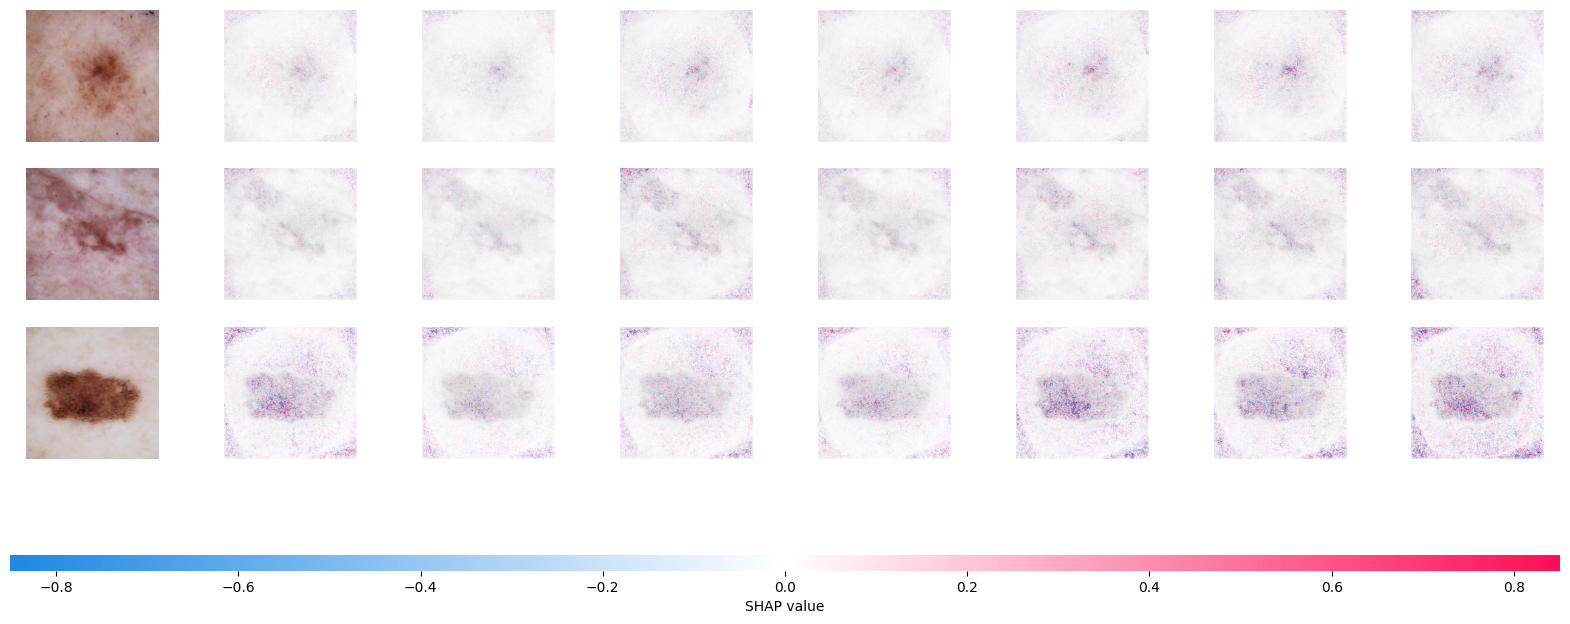

In [77]:
import numpy as np
import shap

# 1. Denormalize your original images (This is working perfectly!)
test_numpy = images_to_explain.cpu().numpy().transpose(0, 2, 3, 1)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
test_numpy_denorm = np.clip((test_numpy * std) + mean, 0, 1)

# 2. Fix the 4-Column Bug by explicitly targeting your 7 classes
if not isinstance(shap_values, list):
    sv = shap_values.cpu().numpy() if hasattr(shap_values, 'cpu') else np.array(shap_values)
    
    if sv.ndim == 5:
        # If shape is [Batch, Channels, Height, Width, Classes] -> (3, 3, 224, 224, 7)
        if sv.shape[-1] == 7: 
            # Move Classes (axis 4) to front, Channels (axis 1) to back
            sv = np.transpose(sv, (4, 0, 2, 3, 1))
            
        # Or if shape is [Batch, Classes, Channels, Height, Width] -> (3, 7, 3, 224, 224)
        elif sv.shape[1] == 7: 
            # Move Classes (axis 1) to front, Channels (axis 2) to back
            sv = np.transpose(sv, (1, 0, 3, 4, 2))
    
    # Because '7' is now the first dimension, this perfectly creates a list of 7 classes
    shap_numpy = [s for s in sv]

else:
    # Fallback if SHAP returned a list directly
    shap_numpy = []
    for s in shap_values:
        s = s.cpu().numpy() if hasattr(s, 'cpu') else s
        if s.ndim == 4 and s.shape[1] == 3:
            s = np.transpose(s, (0, 2, 3, 1))
        shap_numpy.append(s)

# 3. Plot the final explanations
shap.image_plot(shap_numpy, test_numpy_denorm)